In [1]:
import re
import numpy as np
import pandas as pd
import itertools
from tqdm.auto import tqdm

import matplotlib.pyplot as plt


from bert_score import score
import pymorphy3
from rapidfuzz.distance import Levenshtein
from sacrebleu.metrics import BLEU, CHRF


import warnings
import logging
from transformers import logging as hf_logging

warnings.filterwarnings("ignore")

hf_logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("bert_score").setLevel(logging.ERROR)

In [2]:
files = {
    1: "c2_augmented_one_times_translated_fi.csv",
    3: "c2_augmented_three_times_translated.csv",
    5: "c2_augmented_five_times_translated.csv",
    7: "c2_augmented_seven_times_translated.csv",
    9: "c2_augmented_nine_times_translated.csv",
}

# Вспомогательные функции подсчета метрик

In [3]:
morph = pymorphy3.MorphAnalyzer()

def tokenize_words(text):
    text = str(text).lower()
    return re.findall(r"[а-яёa-z]+", text)


def lemmatize_text(text):
    words = tokenize_words(text)
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return lemmas

In [4]:
def bertscore_pair(original_text, augmented_text, model_type="DeepPavlov/rubert-base-cased"):
    """
    Считает BERTScore между двумя текстами:
    original_text — исходный текст
    augmented_text — сгенерированный / аугментированный текст
    """

    P, R, F1 = score(
        [augmented_text],      # candidate
        [original_text],       # reference
        model_type=model_type,
        num_layers=12,
        lang="ru",
        verbose=False
    )

    return {
        "precision": P.item(),
        "recall": R.item(),
        "f1": F1.item()
    }

In [5]:
bleu_metric = BLEU(effective_order=True)
chrf_metric = CHRF()


def jaccard_similarity_lemmas(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas and not aug_lemmas:
        return 1.0

    if not orig_lemmas or not aug_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas | aug_lemmas)


def common_words_ratio(original, augmented):
    """
    Доля лемм исходного текста, которые сохранились в аугментированном.
    """
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas)


def normalized_levenshtein_distance(original, augmented):
    """
    0 — тексты одинаковые.
    1 — тексты максимально различаются.
    """
    original = str(original)
    augmented = str(augmented)

    max_len = max(len(original), len(augmented))

    if max_len == 0:
        return 0.0

    distance = Levenshtein.distance(original, augmented)
    return distance / max_len


def normalized_levenshtein_similarity(original, augmented):
    """
    1 — тексты одинаковые.
    0 — тексты максимально различаются.
    """
    return 1 - normalized_levenshtein_distance(original, augmented)

In [6]:
def lcs_length(x, y):
    """
    Longest Common Subsequence для двух списков токенов.
    """
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if x[i] == y[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    return dp[m][n]


def rouge_l_f1(original, augmented):
    orig_tokens = tokenize_words(original)
    aug_tokens = tokenize_words(augmented)

    if not orig_tokens or not aug_tokens:
        return 0.0

    lcs = lcs_length(orig_tokens, aug_tokens)

    precision = lcs / len(aug_tokens)
    recall = lcs / len(orig_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

In [7]:
def bleu_score(original, augmented):
    """
    BLEU: насколько n-граммы аугментированного текста совпадают с исходным.
    Значение приводим к диапазону 0–1.
    """
    score = bleu_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100


def chrf_score(original, augmented):
    """
    chrF: сходство на уровне символьных n-грамм.
    Значение приводим к диапазону 0–1.
    """
    score = chrf_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100

# Сравнение исходных и аугментированных текстов внутри одной температуры

In [8]:
def calculate_pair_metrics(original, augmented):
    return {
        "bert_score": bertscore_pair(original, augmented),
        "jaccard_lemmas": jaccard_similarity_lemmas(original, augmented),
        "common_words_ratio": common_words_ratio(original, augmented),
        "levenshtein_distance": normalized_levenshtein_distance(original, augmented),
        "levenshtein_similarity": normalized_levenshtein_similarity(original, augmented),
        "rouge_l": rouge_l_f1(original, augmented),
        "bleu": bleu_score(original, augmented),
        "chrf": chrf_score(original, augmented),
    }

In [9]:
all_rows = []

for translation_count, path in files.items():
    df = pd.read_csv(path)

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Обработка строк"):
        original = row['text']
        augmented = row['augmented-text']

        metrics = calculate_pair_metrics(original, augmented)

        metrics["translation_count"] = translation_count
        metrics["original"] = original
        metrics["augmented"] = augmented

        all_rows.append(metrics)

pair_metrics_df = pd.DataFrame(all_rows)

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

In [10]:
pair_metrics_df['bert_score_precision'] = [pair_metrics_df['bert_score'][i]['precision'] for i in range(len(pair_metrics_df))]
pair_metrics_df['bert_score_recall'] = [pair_metrics_df['bert_score'][i]['recall'] for i in range(len(pair_metrics_df))]
pair_metrics_df['bert_score_f1'] = [pair_metrics_df['bert_score'][i]['f1'] for i in range(len(pair_metrics_df))]

del pair_metrics_df['bert_score']

pair_metrics_df

,jaccard_lemmas,common_words_ratio,levenshtein_distance,levenshtein_similarity,rouge_l,bleu,chrf,translation_count,original,augmented,bert_score_precision,bert_score_recall,bert_score_f1
0,0.411765,0.583333,0.430939,0.569061,0.392157,0.196086,0.524398,1,"3:38–3:54 Собственно, сама по себе радиация не...",3:38–3:54 На самом деле радиация не заразна. Н...,0.775861,0.759988,0.767842
1,0.689655,0.769231,0.377880,0.622120,0.576923,0.191701,0.631853,1,Недавно компания Uber объявила об инвестиции о...,Uber недавно объявил об инвестициях в миллиард...,0.837157,0.811666,0.824215
2,0.681818,0.750000,0.569620,0.430380,0.512821,0.553241,0.689427,1,"Множество повестей: «Двойник», «Дядюшкин сон»,...",В творчестве великого писателя было много расс...,0.877201,0.858238,0.867616
3,0.433333,0.541667,0.370370,0.629630,0.510638,0.165823,0.578328,1,Встречи одноклассников и одногруппников превра...,Встречи одноклассников и одноклассников превра...,0.711352,0.630465,0.668470
4,0.473684,0.666667,0.347826,0.652174,0.580645,0.354536,0.659025,1,Самопрезентация — как главная черта времени и ...,Самопрезентация – это одновременно визитная ка...,0.779142,0.796302,0.787628
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.457143,0.666667,0.372881,0.627119,0.508475,0.282829,0.608173,9,00:00:24 А сегодня испытания. 13 участников. Ж...,00:00:24 А сегодня испытание. В нем приняли уч...,0.796014,0.819450,0.807562
596,0.470588,0.592593,0.576923,0.423077,0.384615,0.115720,0.422176,9,«Прома» способна предложить дилерам вполне бож...,Прома предлагает дилерам очень выгодные цены н...,0.746454,0.671990,0.707267
597,0.687500,0.916667,0.239316,0.760684,0.763636,0.463007,0.757582,9,Tesla — не единственный игрок на рынке: больши...,Tesla — не единственный игрок на рынке. Больши...,0.855075,0.888119,0.871284
598,0.361111,0.500000,0.598930,0.401070,0.240000,0.082531,0.362760,9,"Понятно, что среди крупнейших стран – поставщи...","Понятно, что Китай и Индия входят в число стра...",0.609855,0.571338,0.589968


In [12]:
metric_columns = [
    "bert_score_precision",
    "bert_score_recall",
    "bert_score_f1",
    "jaccard_lemmas",
    "common_words_ratio",
    "levenshtein_distance",
    "levenshtein_similarity",
    "rouge_l",
    "bleu",
    "chrf",
]

results_df = (
    pair_metrics_df
    .groupby("translation_count")[metric_columns]
    .agg(["mean", "std", "min", "max"])
)

In [13]:
results_df_flat = results_df.copy()

results_df_flat.columns = [
    f"{metric}_{stat}"
    for metric, stat in results_df_flat.columns
]

results_df_flat = results_df_flat.reset_index()

In [14]:
results_df['bert_score_precision']

,mean,std,min,max
translation_count,,,,
1,0.834726,0.076341,0.574616,1.000000
3,0.755845,0.085560,0.530770,0.949258
5,0.739110,0.110560,0.374354,0.970789
7,0.751770,0.090793,0.510496,0.922277
9,0.694773,0.096200,0.468424,0.875367


In [15]:
results_df['bert_score_recall']

,mean,std,min,max
translation_count,,,,
1,0.820116,0.083406,0.548022,1.000000
3,0.736107,0.095984,0.506781,0.945810
5,0.666745,0.141621,0.201729,0.959525
7,0.724160,0.102747,0.481880,0.948133
9,0.661482,0.107209,0.410607,0.888119


In [16]:
results_df['bert_score_f1']

,mean,std,min,max
translation_count,,,,
1,0.827066,0.078772,0.561004,1.000000
3,0.745454,0.089708,0.518498,0.947531
5,0.699040,0.126153,0.262178,0.965124
7,0.737297,0.095826,0.495776,0.929751
9,0.677220,0.100768,0.442418,0.877372


In [17]:
results_df['jaccard_lemmas']

,mean,std,min,max
translation_count,,,,
1,0.604458,0.145928,0.156250,1.000000
3,0.482474,0.145851,0.193548,0.880000
5,0.435908,0.169982,0.000000,0.869565
7,0.454163,0.145037,0.170732,0.814815
9,0.379279,0.142130,0.088235,0.730769


In [20]:
results_df['common_words_ratio']

,mean,std,min,max
translation_count,,,,
1,0.734695,0.123487,0.277778,1.000000
3,0.626920,0.137920,0.333333,0.920000
5,0.535317,0.185724,0.000000,0.952381
7,0.594683,0.140814,0.277778,0.916667
9,0.514362,0.158573,0.136364,0.916667


In [21]:
results_df['levenshtein_distance']

,mean,std,min,max
translation_count,,,,
1,0.300860,0.129114,0.000000,0.815534
3,0.443567,0.141053,0.101695,0.765550
5,0.472579,0.164019,0.114504,0.923977
7,0.434685,0.151909,0.089286,0.841176
9,0.515154,0.133540,0.174419,0.804878


In [22]:
results_df['levenshtein_similarity']

,mean,std,min,max
translation_count,,,,
1,0.699140,0.129114,0.184466,1.000000
3,0.556433,0.141053,0.234450,0.898305
5,0.527421,0.164019,0.076023,0.885496
7,0.565315,0.151909,0.158824,0.910714
9,0.484846,0.133540,0.195122,0.825581


In [25]:
results_df['rouge_l']

,mean,std,min,max
translation_count,,,,
1,0.641035,0.140819,0.166667,1.000000
3,0.484214,0.150165,0.150943,0.851064
5,0.461956,0.174266,0.000000,0.883721
7,0.474917,0.151831,0.162162,0.880000
9,0.379409,0.152374,0.058824,0.791667


In [24]:
results_df['bleu']

,mean,std,min,max
translation_count,,,,
1,0.402046,0.188862,0.046959,1.000000
3,0.233031,0.152279,0.024943,0.794834
5,0.221942,0.162588,0.000034,0.711527
7,0.237885,0.158705,0.039936,0.794834
9,0.164017,0.124288,0.018718,0.642377


In [23]:
results_df['chrf']

,mean,std,min,max
translation_count,,,,
1,0.667153,0.116746,0.402600,1.000000
3,0.548100,0.121135,0.296937,0.843566
5,0.488875,0.153546,0.039195,0.817824
7,0.530888,0.130012,0.278016,0.893377
9,0.459118,0.125429,0.187484,0.777184


In [18]:
def plot_pairwise_metric(results_df, metric_name, title, ylabel):
    plt.figure(figsize=(8, 5))

    plt.plot(
        results_df["translation_count"],
        results_df[f"{metric_name}_mean"],
        marker="o"
    )

    plt.xticks([1,3,5,7,9])
    plt.xlabel("Количество переводов")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()

    plt.show()

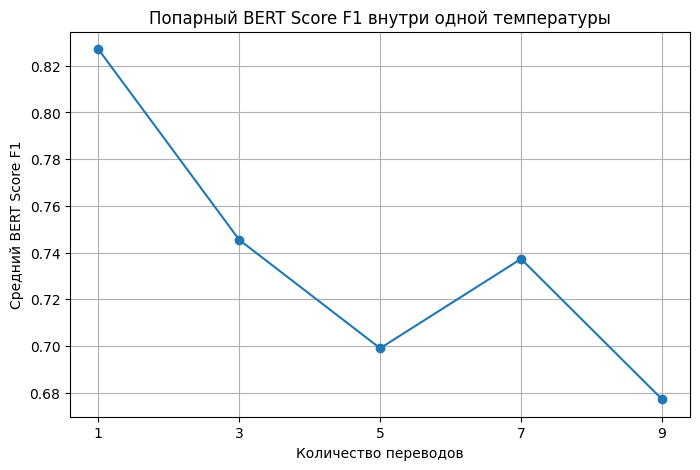

In [26]:
plot_pairwise_metric(
    results_df_flat,
    "bert_score_f1",
    "Попарный BERT Score F1 внутри одной температуры",
    "Средний BERT Score F1"
)

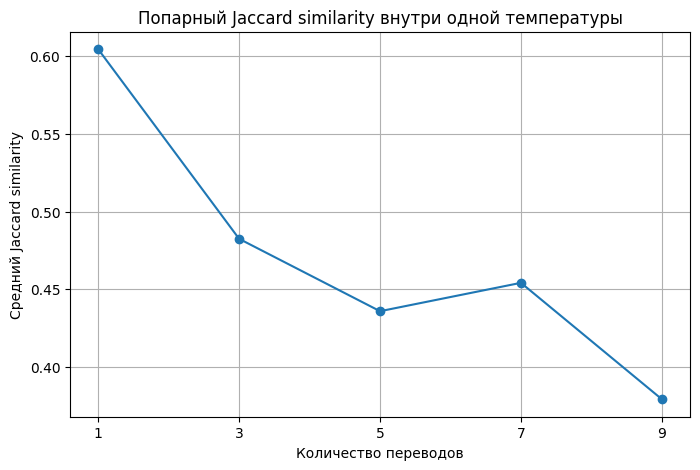

In [27]:
plot_pairwise_metric(
    results_df_flat,
    "jaccard_lemmas",
    "Попарный Jaccard similarity внутри одной температуры",
    "Средний Jaccard similarity"
)